In [1]:
import os
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import numpy.random as nr
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import scipy
import pickle

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))


from src.safe_routing import*
from src.preprocess import preprocess_df

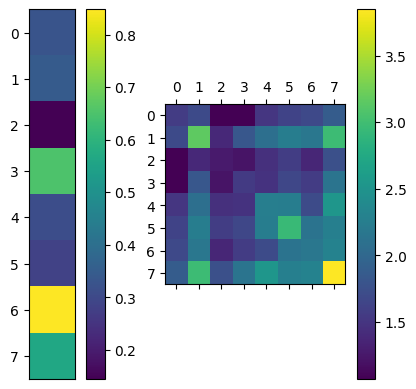

In [2]:
seed = 232# 232
np.random.seed(seed)

n_max = 8
mu_all = nr.rand(n_max)#np.zeros(n_max)  # nr.rand(n_max)
A_all = nr.rand(n_max, n_max)
cov_all = np.dot(A_all, A_all.T)

ax1 = plt.subplot(121)
mat1 = ax1.matshow(mu_all.reshape((-1, 1)))
plt.colorbar(mat1)
ax1.set_xticks([], [])
ax2 = plt.subplot(122)
mat2 = ax2.matshow(cov_all)
plt.colorbar(mat2)


In [4]:
res_df = pd.DataFrame()
all_true_mean = []
n_dims = list(np.arange(3, n_max, 1))
for n_dim in n_dims:
    print(n_dim)
    mu = mu_all[:n_dim]
    cov = cov_all[:n_dim, :n_dim]
    #temp_df = naive_mc_max(mu, cov, 10000, 10)
    temp_df['n_dim'] = n_dim
    res_df = pd.concat((res_df, temp_df))
    all_true_mean.append(calc_mean_max(cov, mu))


3
4
5
6
7


In [15]:
import time

n_max = 8
mu_all = nr.rand(n_max)#np.zeros(n_max)  # nr.rand(n_max)
A_all = nr.rand(n_max, n_max)
cov_all = np.dot(A_all, A_all.T)
n_dim = 8

mu = mu_all[:n_dim]
cov = cov_all[:n_dim, :n_dim]

start = time.time()
calc_mean_max(cov, mu)
#temp_df = naive_mc_max(mu, cov, 10000, 10)
end = time.time()
print(end - start)


73.90212535858154


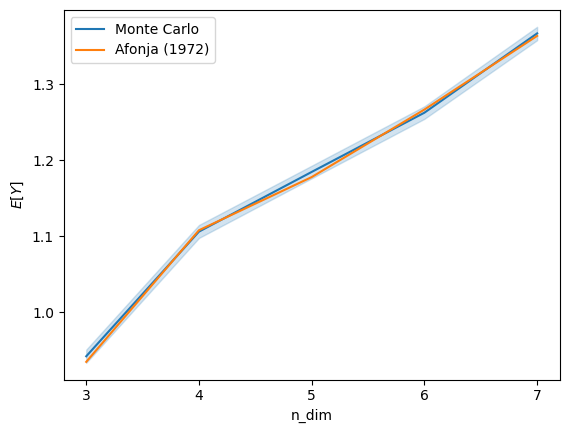

In [6]:
sns.lineplot(data=res_df, x='n_dim', y='max', label='Monte Carlo')
plt.plot(n_dims, all_true_mean, label='Afonja (1972)')
plt.ylabel(r'$E[Y]$')
plt.xticks([i for i in n_dims], [i for i in n_dims])
plt.legend()

In [19]:
all_true_mean

[0.9342835750223697,
 1.1077661470152813,
 1.1778591546398856,
 1.2668770677049193,
 1.3640323919068835]

# Simple Safe Routing on CIC-IDS-2017

In [2]:
import importlib, src

importlib.reload(src.safe_routing)
from src.safe_routing import*

In [2]:
with open('internal_nodes_tuesday.pickle', 'rb') as handle:
    entity_names = pickle.load(handle) 

In [14]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
    base_names = pickle.load(handle) 

In [2]:
with open('attack_rel_nodes.pickle', 'rb') as handle:
    entity_names = pickle.load(handle) 

In [27]:
with open('tuesday_freq_1000.pickle', 'rb') as handle:
    entity_names = pickle.load(handle) 

In [ ]:
with open('sample_nodes.pickle', 'rb') as handle:
    entity_names = pickle.load(handle) 

In [3]:
with open('partitioned_nodes.pickle', 'rb') as handle:
    entity_names = pickle.load(handle) 

In [30]:
entity_names = base_names[:7]

In [3]:
entity_names

['192.168.10.50',
 '192.168.10.51',
 '192.168.10.19',
 '192.168.10.17',
 '192.168.10.16',
 '192.168.10.12',
 '192.168.10.9',
 '192.168.10.5',
 '192.168.10.8',
 '192.168.10.14',
 '192.168.10.15',
 '192.168.10.25']

In [31]:
entity_names

['192.168.10.3',
 '192.168.10.50',
 '192.168.10.51',
 '192.168.10.19',
 '192.168.10.17',
 '192.168.10.16',
 '192.168.10.12']

In [32]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv' 
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')
df = preprocess_df(df_cic, date_col=' Timestamp')

print(len(entity_names))
g = communication_graph_from_df(df, entity_names, keep_outsiders=False)

7


In [5]:
len(g)

12

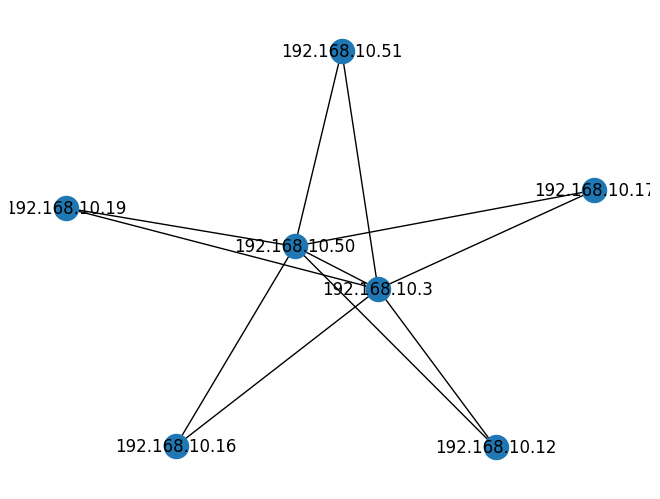

In [33]:
pos = nx.spring_layout(g)
nx.draw(g, pos=pos, with_labels=True)

In [34]:
import importlib, src, src.analyze_cic_ids

importlib.reload(src.analyze_cic_ids)
from src.analyze_cic_ids import*

In [35]:
import importlib, src, src.kalman_network_tools

importlib.reload(src.kalman_network_tools)
from src.kalman_network_tools import*

In [36]:
from src.analyze_cic_ids import get_risk_mat_from_df

risk_mat, labels, labels_count, _, _, all_cov = get_risk_mat_from_df(df, entity_names=entity_names, t_graph=180, sync_window_size=1.2,
                                                                    return_cov=True)
risk_mean, risk_cov = risk_mat[-1,:], all_cov[-1]

with open(r'saves\risks_insider2.pickle', 'wb') as handle: # sample_nodes.pickle
    pickle.dump((risk_mean, risk_cov), handle, protocol=pickle.HIGHEST_PROTOCOL)


1
Current time and samples shape:  2017-04-07 01:03:00 (150, 7)
2
Current time and samples shape:  2017-04-07 01:06:00 (150, 7)
3
Current time and samples shape:  2017-04-07 01:09:00 (150, 7)
4
Current time and samples shape:  2017-04-07 01:12:00 (150, 7)
5
Current time and samples shape:  2017-04-07 01:15:00 (150, 7)
6
Current time and samples shape:  2017-04-07 01:18:00 (150, 7)
7
Current time and samples shape:  2017-04-07 01:21:00 (150, 7)
8
Current time and samples shape:  2017-04-07 01:24:00 (150, 7)
9
Current time and samples shape:  2017-04-07 01:27:00 (150, 7)
10
Current time and samples shape:  2017-04-07 01:30:00 (150, 7)
11
Current time and samples shape:  2017-04-07 01:33:00 (150, 7)
12
Current time and samples shape:  2017-04-07 01:36:00 (150, 7)
13
Current time and samples shape:  2017-04-07 01:39:00 (150, 7)
14
Current time and samples shape:  2017-04-07 01:42:00 (150, 7)
15
Current time and samples shape:  2017-04-07 01:45:00 (150, 7)
16
Current time and samples shape:

127
Current time and samples shape:  2017-04-07 11:11:00 (150, 7)
128
Current time and samples shape:  2017-04-07 11:14:00 (150, 7)
129
Current time and samples shape:  2017-04-07 11:17:00 (150, 7)
130
Current time and samples shape:  2017-04-07 11:20:00 (150, 7)
131
Current time and samples shape:  2017-04-07 11:23:00 (150, 7)
132
Current time and samples shape:  2017-04-07 11:26:00 (150, 7)
133
Current time and samples shape:  2017-04-07 11:29:00 (150, 7)
134
Current time and samples shape:  2017-04-07 11:32:00 (150, 7)
135
Current time and samples shape:  2017-04-07 11:35:00 (150, 7)
136
Current time and samples shape:  2017-04-07 11:38:00 (150, 7)
137
Current time and samples shape:  2017-04-07 11:41:00 (150, 7)
138
Current time and samples shape:  2017-04-07 11:44:00 (150, 7)
139
Current time and samples shape:  2017-04-07 11:47:00 (150, 7)
140
Current time and samples shape:  2017-04-07 11:50:00 (150, 7)
141
Current time and samples shape:  2017-04-07 11:53:00 (150, 7)
142
Curren

In [37]:
with open(r'saves\risks_insider.pickle', 'rb') as handle:
    risk_mean, risk_cov = pickle.load(handle) 

In [38]:
risk_mean

array([0.31779731, 0.31799003, 0.31046327, 0.23158027, 0.26569623,
       0.24663577, 0.30430386, 0.20269174, 0.32164317, 0.22723295,
       0.22117688, 0.24456225, 0.34488089])

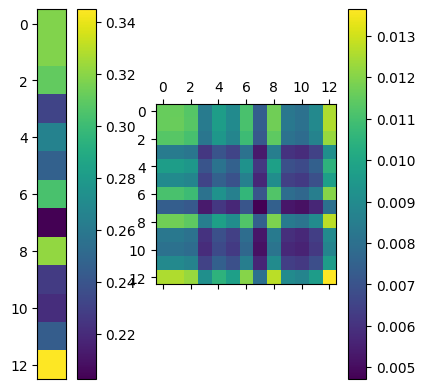

In [39]:


ax1 = plt.subplot(121)
mat1 = ax1.matshow(risk_mean.reshape((-1, 1)))
plt.colorbar(mat1)
ax1.set_xticks([], [])
ax2 = plt.subplot(122)
mat2 = ax2.matshow(risk_cov)
plt.colorbar(mat2)

<Axes: ylabel='max'>

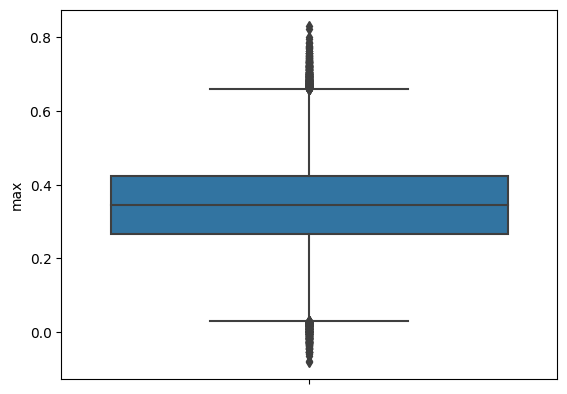

In [40]:

temp_df = naive_mc_max(risk_mean, risk_cov, 10000, 10)
sns.boxplot(data=temp_df, y='max')

In [41]:
source = '192.168.10.15' # 9
g = communication_graph_from_df(df, entity_names, keep_outsiders=False)
risk_dict = {node:risk for node, risk in zip(g.nodes, risk_mean)}
distances = safest_path(g, source, risk_dict)


KeyError: '192.168.10.15'

In [ ]:
import src.network_plotting, importlib

importlib.reload(src.network_plotting)
from src.network_plotting import*

In [ ]:
fig = cartesian_dist_plot(g, distances, risk_dict, '' )

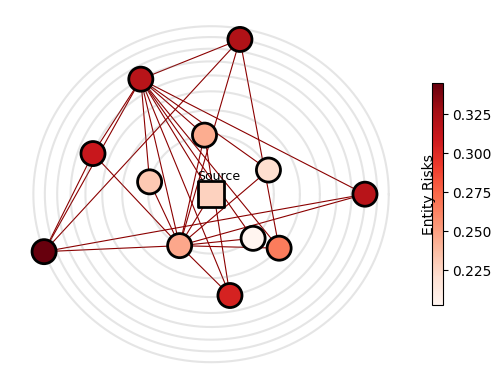

In [13]:
fig = polar_dist_plot(g, distances, risk_dict, '', seed=19) # 95

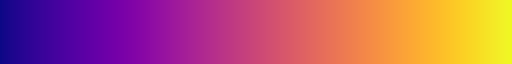

In [101]:
plt.cm.plasma

In [67]:
node_clr = [risk_dict[node] for node in g.nodes]

norm = matplotlib.colors.Normalize(vmin=min(node_clr), vmax=max(node_clr))
norm(.24)

0.6995471504525363

In [26]:
risk_dict

{'192.168.10.50': 0.3313895261973516,
 '192.168.10.16': 0.3381013178710596,
 '192.168.10.12': 0.23737384671368858,
 '192.168.10.51': 0.2722545596387951,
 '192.168.10.8': 0.26611514684228554,
 '192.168.10.5': 0.31693554013514286,
 '192.168.10.25': 0.21495611664175748,
 '192.168.10.17': 0.33228553083638424,
 '192.168.10.19': 0.24505489634686475,
 '192.168.10.14': 0.2457661499716785,
 '192.168.10.15': 0.25589171438630987,
 '192.168.10.9': 0.36274082508200295}

In [27]:
distances

{'192.168.10.15': 0.25589171438630987,
 '192.168.10.50': 0.3313895261973516,
 '192.168.10.12': 0.3313895261973516,
 '192.168.10.51': 0.3313895261973516,
 '192.168.10.8': 0.3313895261973516,
 '192.168.10.5': 0.3313895261973516,
 '192.168.10.25': 0.3313895261973516,
 '192.168.10.19': 0.3313895261973516,
 '192.168.10.14': 0.3313895261973516,
 '192.168.10.17': 0.33228553083638424,
 '192.168.10.16': 0.3381013178710596,
 '192.168.10.9': 0.36274082508200295}

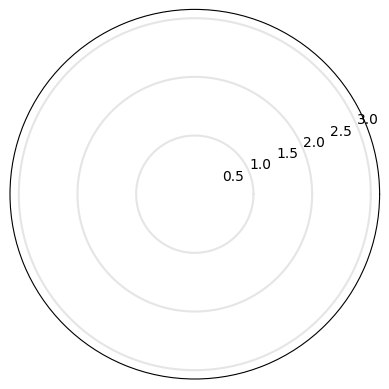

In [26]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

n_points = 1000
thetas = np.linspace(0, 2*np.pi, n_points)

for r in range(4):
    ax.plot(thetas, [r for _ in range(n_points)], 'tab:gray', alpha= .2)

ax.set_thetagrids(angles=[0], labels=[''])
ax.grid(False)
#nx.draw(g, with_labels=True, ax=ax)


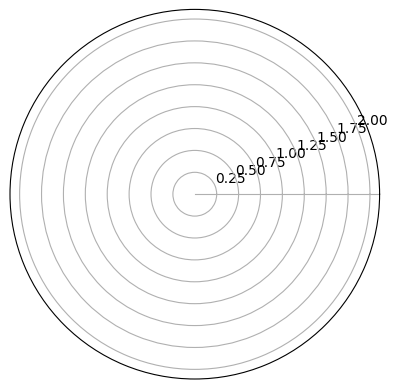

In [41]:
fig.axes[0].plot(2, 2)
fig

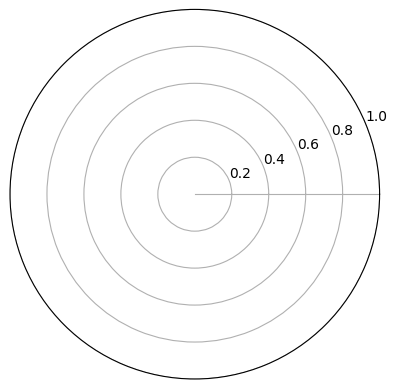

In [36]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
#ax.set_rmax(2)
#ax.set_rticks([0.5, 1, 1.5, 2])
plt.thetagrids(angles=[0], labels=[''])
ax.grid(True)

# MCMC

Progress: [##############################] 1000 of 1000 samples


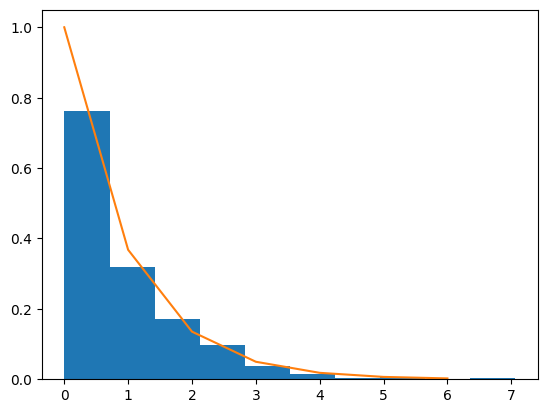

In [9]:
import sampyl.samplers as smp

logp = lambda x: -x if x > 0 else -np.inf
metro = smp.Metropolis(logp, {'x': 1})
samps = metro.sample(1000)
samps.shape
plt.hist(samps.x, density= True)
plt.plot(np.exp(-np.arange(7)))

# Miscellaneous Plots

Text(0, 0.5, '$f_X(x)$')

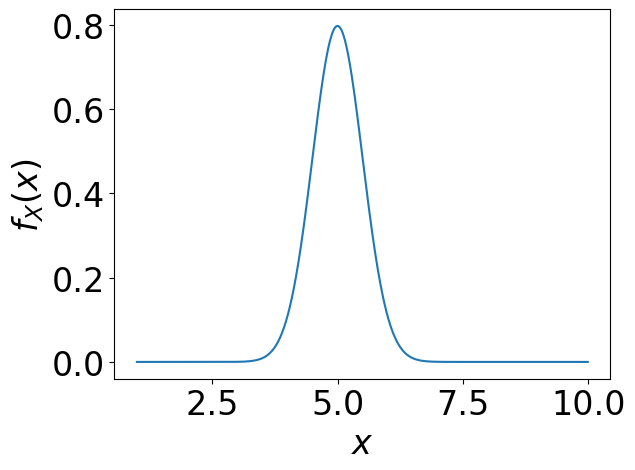

In [103]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import statistics
  
# Plot between -10 and 10 with .001 steps.
x_axis = np.arange(1, 10, 0.01)

plt.rcParams.update({'font.size': 24})
plt.plot(x_axis, norm.pdf(x_axis, 5, 0.5))
plt.xlabel(r'$x$')
plt.ylabel(r'$f_X(x)$')

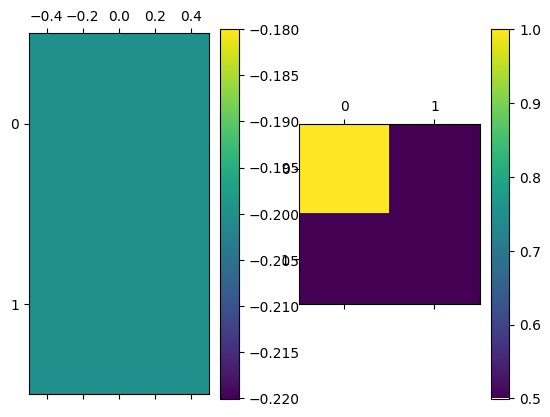

In [21]:
seed = 232
np.random.seed(seed)

n = 2

mu = np.array([-.2,-.2])
cov = np.array([[1, 0.5],
                [0.5, 0.5]])

ax1 = plt.subplot(121)
mat1 = ax1.matshow(mu.reshape((-1, 1)))
plt.colorbar(mat1)
ax2 = plt.subplot(122)
mat2 = ax2.matshow(cov)
plt.colorbar(mat2)

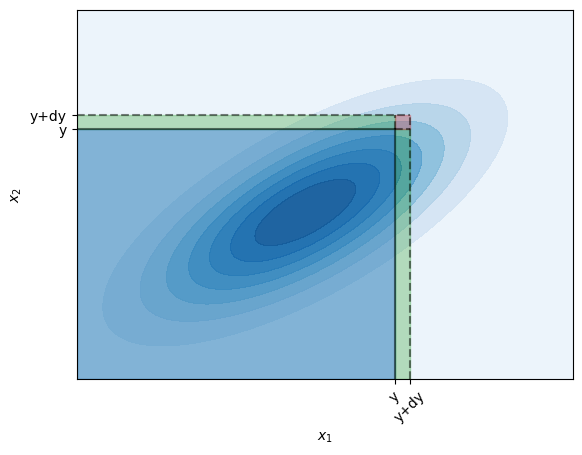

In [79]:
from scipy.stats import multivariate_normal

rv = multivariate_normal(mean= mu, cov= cov, allow_singular=False)

y_min, y_max = -2, 2
x_min, x_max = -2.5, 2.5
eps = 0.15

x, y = np.mgrid[x_min:x_max:.01, y_min:y_max:.01]
pos = np.dstack((x, y))
fig = plt.figure()
ax = fig.add_subplot(111)
ax.contourf(x, y, rv.pdf(pos), alpha= 0.9, cmap='Blues')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
#fig.savefig(fname='./figures/mvn.jpg')

y_val = 0.7
ax.plot([y_val, y_val], [y_min, y_val], color= 'k', alpha= 0.5)#, linestyle='dashed'
ax.plot([x_min, y_val], [y_val, y_val], color= 'k', alpha= 0.5)
ax.set_xticks([y_val], ['y'])
ax.set_yticks([y_val], ['y'])
ax.fill_between([x_min, y_val], [y_min, y_min], [y_val, y_val], color='tab:blue', alpha=0.3)
fig.savefig(fname='./figures/mvn_y.jpg')

ax.plot([y_val, y_val], [y_val, y_val+eps], color= 'k', alpha= 0.5, linestyle='dashed')
ax.plot([y_val, y_val+eps], [y_val, y_val], color= 'k', alpha= 0.5, linestyle='dashed')
ax.plot([y_val+eps, y_val+eps], [y_min, y_val+eps], color= 'k', alpha= 0.5, linestyle='dashed')
ax.plot([x_min, y_val+eps], [y_val+eps, y_val+eps], color= 'k', alpha= 0.5, linestyle='dashed')
ax.set_xticks([y_val, y_val+eps], ['y', 'y+dy'], rotation= 45)
ax.set_yticks([y_val, y_val+eps], ['y', 'y+dy'])
#fig.savefig(fname='./figures/mvn_y_dy.jpg')

ax.fill_between([x_min, y_val], [y_min, y_min], [y_val, y_val], color='tab:blue', alpha=0.3)
ax.fill_between([x_min, y_val], [y_val, y_val], [y_val+eps, y_val+eps], color='tab:green', alpha=0.3)
ax.fill_between([y_val, y_val+eps], [y_min, y_min], [y_val, y_val], color='tab:green', alpha=0.3)
ax.fill_between([y_val, y_val+eps], [y_val, y_val], [y_val+eps, y_val+eps], color='tab:red', alpha=0.3)
#fig.savefig(fname='./figures/mvn_y_dy_shaded.jpg')